# Affine brute force

In [1]:
import os

# Obtener el directorio actual en Jupyter Notebook
directorio_actual = os.getcwd()

# Buscar el directorio raíz "Cryptography"
while not os.path.basename(directorio_actual) == "Cryptography":
    directorio_actual = os.path.dirname(directorio_actual)  # Retroceder un nivel

# Construir la ruta del archivo cifrado
ruta_archivo = os.path.join(directorio_actual, "Cifrados", "afines.txt")

# Verificar si el archivo existe antes de abrirlo
if os.path.exists(ruta_archivo):
    with open(ruta_archivo, "r", encoding="utf-8") as file:
        mensaje_cifrado = file.read().strip().upper()
    print(f"Archivo cargado desde: {ruta_archivo}")
else:
    print(f"❌ Error: No se encontró el archivo en {ruta_archivo}")

Archivo cargado desde: /Users/mvrcentes/Library/CloudStorage/OneDrive-UVG/Documentos/Semestre_9/Cryptography/Cifrados/afines.txt


In [13]:
import string
import matplotlib.pyplot as plt
from prettytable import PrettyTable
from collections import Counter
from colorama import init, Fore, Style
from dic import words

# Inicializar colorama
init(autoreset=True)

# 📌 Definir el alfabeto en español con la "Ñ"
ALFABETO = "ABCDEFGHIJKLMNÑOPQRSTUVWXYZ"

# 📌 Distribución teórica de frecuencias en español
distribucion_teorica = {
    "A": 12.53, "B": 1.42, "C": 4.68, "D": 5.86, "E": 13.68, "F": 0.69, "G": 1.01, "H": 0.70,
    "I": 6.25, "J": 0.44, "K": 0.02, "L": 4.97, "M": 3.15, "N": 6.71, "Ñ": 0.31, "O": 8.68,
    "P": 2.51, "Q": 0.88, "R": 6.87, "S": 7.98, "T": 4.63, "U": 3.93, "V": 0.90, "W": 0.01,
    "X": 0.22, "Y": 0.90, "Z": 0.52
}

mensaje_cifrado.strip().upper()

'ZIGIUÑPJDIPOZIYICBDODDIYXBÑHJORBPBDODCIÑMIDIIAHXOIXDIPJCOHOSMICIOXHTPIIDMRDIPIXXJXXIQIPJMZODITBPBDODYXMYBOPSMIÑIXUBHBJOPJCOHOYOZHICPIIXPOUIUJXBODIUBPICDICBCHIUOCFXJTOXBZNJXUOYBJZQOPBJCOOCIUÑXICOCSMIPJRXOXJZXIYMÑIXOXCIXOÑBDOUIZHINMIXJZPOCSMIDIUJCHXOXJZYXBÑHJORBPBDODXIIUÑPOKOZDJXOÑBDOUIZHICMCYPOQICYXBÑHJRXONBYOCFOPRJXBHUJCYJUÑXJUIHBDJCÑJXJHXJCZMIQJCFCIRMXJCCHIBZYBDIZHICBXQIYJUJMZYPOXJIGIUÑPJDIPOBUÑJXHOZYBODIPOYXBÑHJORBPBDODIZZMICHXOTOHOPPOYJZHBZMOYJZHXOPOCOUIZOKOCDBZOUBYOCDIYBTIXCIRMXBDOD'

## Calcular la frencuencia observable

In [7]:
def analizar_frecuencia(texto):
    """Calcula la frecuencia de letras en el texto cifrado."""
    total = len(texto)
    frecuencia = Counter(texto.upper())

    # Filtrar solo letras del alfabeto español
    frecuencia_filtrada = {letra: (frecuencia[letra] / total) * 100 for letra in distribucion_teorica.keys() if letra in frecuencia}
    
    return frecuencia_filtrada

# 📌 Calcular la frecuencia observada
frecuencia_observada = analizar_frecuencia(mensaje_cifrado)

# 📊 Crear tabla de frecuencias
tabla_frecuencia = PrettyTable(["Letra", "Frecuencia (%)", "Teórica (%)", "Diferencia (%)"])
for letra in sorted(frecuencia_observada.keys(), key=lambda x: frecuencia_observada[x], reverse=True):
    teorica = distribucion_teorica[letra]
    observada = frecuencia_observada[letra]
    diferencia = round(abs(teorica - observada), 2)
    tabla_frecuencia.add_row([letra, round(observada, 2), teorica, diferencia])

print("📊 Comparación de Frecuencias")
print(tabla_frecuencia)

📊 Comparación de Frecuencias
+-------+----------------+-------------+----------------+
| Letra | Frecuencia (%) | Teórica (%) | Diferencia (%) |
+-------+----------------+-------------+----------------+
|   I   |     13.03      |     6.25    |      6.78      |
|   O   |     12.22      |     8.68    |      3.54      |
|   X   |      8.76      |     0.22    |      8.54      |
|   J   |      7.74      |     0.44    |      7.3       |
|   B   |      7.54      |     1.42    |      6.12      |
|   C   |      6.92      |     4.68    |      2.24      |
|   D   |      6.31      |     5.86    |      0.45      |
|   P   |      5.7       |     2.51    |      3.19      |
|   H   |      4.89      |     0.7     |      4.19      |
|   Z   |      4.89      |     0.52    |      4.37      |
|   Y   |      4.28      |     0.9     |      3.38      |
|   U   |      4.07      |     3.93    |      0.14      |
|   M   |      3.46      |     3.15    |      0.31      |
|   Ñ   |      3.26      |     0.31    |   

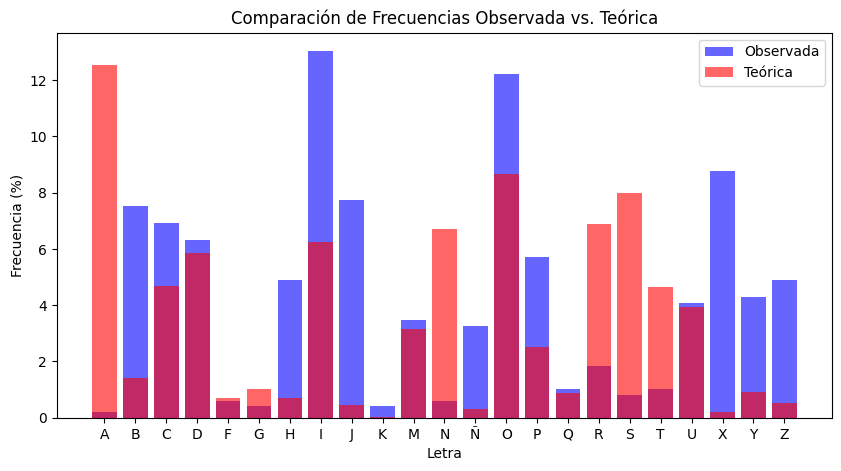

In [8]:
# 📊 Crear gráfico comparativo
letras = list(frecuencia_observada.keys())
observada = [frecuencia_observada[letra] for letra in letras]
teorica = [distribucion_teorica[letra] for letra in letras]

plt.figure(figsize=(10, 5))
plt.bar(letras, observada, alpha=0.6, label="Observada", color="blue")
plt.bar(letras, teorica, alpha=0.6, label="Teórica", color="red")
plt.xlabel("Letra")
plt.ylabel("Frecuencia (%)")
plt.title("Comparación de Frecuencias Observada vs. Teórica")
plt.legend()
plt.show()

In [9]:
def encontrar_clave_afin(frecuencia_observada):
    """Encuentra los valores de 'a' y 'b' en el cifrado afín usando análisis de frecuencia."""
    letra_mas_comun = max(frecuencia_observada, key=frecuencia_observada.get)
    letra_esperada = "E"  # En español, la 'E' es la más común

    x = ALFABETO.index(letra_mas_comun)
    y = ALFABETO.index(letra_esperada)

    print(f"🔍 Letra más común en cifrado: {letra_mas_comun} ({x})")
    print(f"🎯 Letra esperada más común: {letra_esperada} ({y})")

    return x, y

x, y = encontrar_clave_afin(frecuencia_observada)

🔍 Letra más común en cifrado: I (8)
🎯 Letra esperada más común: E (4)


In [14]:
UMBRAL_PALABRAS = 200

def extended_gcd(a, b):
    """Algoritmo de Euclides Extendido para encontrar el MCD y los coeficientes."""
    if a == 0:
        return (b, 0, 1)
    else:
        g, x, y = extended_gcd(b % a, a)
        return (g, y - (b // a) * x, x)

def modular_inverse(a, m):
    """Calcula el inverso modular de 'a' módulo 'm'."""
    g, x, _ = extended_gcd(a, m)
    if g != 1:
        return None  # No tiene inverso modular
    return x % m

def decrypt_affine(texto, a, b):
    """Descifra un texto cifrado con el cifrado Afín."""
    resultado = ""
    a_inv = modular_inverse(a, len(ALFABETO))
    if a_inv is None:
        return None  # Saltar si no tiene inverso

    for char in texto:
        if char in ALFABETO:
            indice = (a_inv * (ALFABETO.index(char) - b)) % len(ALFABETO)
            resultado += ALFABETO[indice]
        else:
            resultado += char  # Mantener otros caracteres
    return resultado

def contar_palabras_validas(texto, diccionario):
    """Cuenta cuántas palabras del diccionario aparecen en el texto sin espacios."""
    palabras_encontradas = 0
    for palabra in diccionario:
        if palabra in texto.lower():
            palabras_encontradas += 1
    return palabras_encontradas

def brute_force_affine(texto_cifrado):
    """Prueba todas las combinaciones de 'a' y 'b' y se detiene si encuentra palabras."""

    mejor_a, mejor_b = None, None
    mejor_texto = ""
    mejor_palabras = 0

    print(Fore.YELLOW + "\n🔹 Iniciando Fuerza Bruta para el Cifrado Afín...")

    for a in range(1, 17):  # Recorrer 'a' en el rango permitido
        if extended_gcd(a, len(ALFABETO))[0] != 1:
            continue  # Saltar si 'a' no es coprimo con el tamaño del alfabeto

        for b in range(1, 17):  # Recorrer 'b' en el rango permitido
            texto_descifrado = decrypt_affine(texto_cifrado, a, b)
            if texto_descifrado is None:
                continue  # Saltar si no se pudo descifrar

            palabras_validas = contar_palabras_validas(texto_descifrado, words)

            # Determinar color basado en cantidad de palabras acertadas
            color = Fore.GREEN if palabras_validas > 10 else Fore.RED

            print(f"{Fore.CYAN}🔹 Probando (a={a}, b={b})")
            print(f"{color}✅ Palabras acertadas: {palabras_validas}")
            print(f"{color}🔓 Resultado: {texto_descifrado[:150]}...")  # Solo primeros 150 caracteres
            print(Style.RESET_ALL)

            # Guardar el mejor resultado
            if palabras_validas > mejor_palabras:
                mejor_palabras = palabras_validas
                mejor_a, mejor_b = a, b
                mejor_texto = texto_descifrado

            # 🚨 **Solo preguntar si supera el umbral de palabras encontradas**
            if palabras_validas >= UMBRAL_PALABRAS:
                print(f"{Fore.YELLOW}\n🔹 Se encontraron muchas palabras en el intento (a={a}, b={b})")
                print(f"{Fore.GREEN}🔓 Texto: {texto_descifrado[:300]}...\n")  # Mostrar hasta 300 caracteres
                
                print("¿Quieres continuar con más claves?")
                print("[1] Continuar probando más claves")
                print("[2] Detenerse y mostrar el mejor resultado")
                
                opcion = input("Selecciona una opción: ").strip()
                
                if opcion == "2":
                    print(f"\n{Fore.YELLOW}🔹 Mejor Clave Encontrada: (a={mejor_a}, b={mejor_b})")
                    print(f"{Fore.GREEN}🔓 Mensaje Descifrado: {mejor_texto[:300]}\n")  # Mostrar hasta 300 caracteres
                    return  # Salir de la función

    # Mostrar el mejor resultado encontrado si no se detuvo antes
    if mejor_a is not None:
        print(f"\n{Fore.YELLOW}🔹 Mejor Clave Encontrada: (a={mejor_a}, b={mejor_b})")
        print(f"{Fore.GREEN}🔓 Mensaje Descifrado: {mejor_texto[:300]}\n")  # Mostrar hasta 300 caracteres

brute_force_affine(mensaje_cifrado)




🔹 Iniciando Fuerza Bruta para el Cifrado Afín...
🔹 Probando (a=1, b=1)
✅ Palabras acertadas: 34
🔓 Resultado: YHFHTNOICHOÑYHXHBACÑCCHXWANGIÑQAOACÑCBHNLHCHHZGWÑHWCHOIBÑGÑRLHBHÑWGSOHHCLQCHOHWWIWWHPHOILYÑCHSAOACÑCXWLXAÑORLHNHWTAGAIÑOIBÑGÑXÑYGHBOHHWOÑTHTIWAÑCHTAOH...

🔹 Probando (a=1, b=2)
✅ Palabras acertadas: 35
🔓 Resultado: XGEGSMÑHBGÑNXGWGAZBNBBGWVZMFHNPZÑZBNBAGMKGBGGYFVNGVBGÑHANFNQKGAGNVFRÑGGBKPBGÑGVVHVVGOGÑHKXNBGRZÑZBNBWVKWZNÑQKGMGVSZFZHNÑHANFNWNXFGAÑGGVÑNSGSHVZNBGSZÑG...

🔹 Probando (a=1, b=3)
✅ Palabras acertadas: 35
🔓 Resultado: WFDFRLNGAFNMWFVFZYAMAAFVUYLEGMOYNYAMAZFLJFAFFXEUMFUAFNGZMEMPJFZFMUEQNFFAJOAFNFUUGUUFÑFNGJWMAFQYNYAMAVUJVYMNPJFLFURYEYGMNGZMEMVMWEFZNFFUNMRFRGUYMAFRYNF...

🔹 Probando (a=1, b=4)
✅ Palabras acertadas: 42
🔓 Resultado: VECEQKMFZEMLVEUEYXZLZZEUTXKDFLÑXMXZLZYEKIEZEEWDTLETZEMFYLDLOIEYELTDPMEEZIÑZEMETTFTTENEMFIVLZEPXMXZLZUTIUXLMOIEKETQXDXFLMFYLDLULVDEYMEETMLQEQFTXLZEQXME...

🔹 Probando (a=1, b=5)
✅ Palabras acertadas: 47
🔓 Resultado: UDBDPJLEYDLKUDTDXWYKYYDTSWJCEK

## Conclusión

Al analizar la frecuencia de las letras en el texto cifrado, encontramos que la letra I aparece con mucha más frecuencia de lo esperado (13.03% en lugar de 6.25%), lo que sugiere que podría haber sustituido una letra común en español, como la E o la A. Por otro lado, la letra A, que normalmente es una de las más utilizadas en español (12.53%), casi no aparece en el texto cifrado (0.2%), lo que indica que fue transformada en otra letra menos esperada.

La comparación de frecuencias entre el texto cifrado y la distribución teórica del español nos permitió detectar anomalías clave y ayudó a identificar posibles sustituciones. Con esta información, aplicamos un ataque de fuerza bruta al cifrado Afín y logramos recuperar la clave correcta (a=5, b=15).


## Referencias

https://thepythoncode.com/article/how-to-crack-the-affine-cipher-in-python
https://github.com/sukhdev01/Attacks-on-Affine-Cipher/blob/master/Brute_force_attacks_on_Affine_cipher.ipynb

GPT 